In [1]:
# 1. Imports & settings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import itertools

# Section 1

In [2]:
# 2. Load data
orders = pd.read_csv("orders.csv", parse_dates=["order_date"])
shipments = pd.read_csv(
    "shipments.csv",
    parse_dates=["ship_date", "delivered_date"]
)
refunds = pd.read_csv("refunds.csv", parse_dates=["refund_date"])

orders.head(), shipments.head(), refunds.head()

(   order_id                           customer_id order_date region  \
 0         1  bdd640fb-0667-4ad1-9c80-317fa3b1799d 2025-02-21  South   
 1         2  23b8c1e9-3924-46de-beb1-3b9046685257 2025-01-15  North   
 2         3  bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9 2025-03-13   West   
 3         4  972a8469-1641-4f82-8b9d-2434e465e150 2025-03-02  North   
 4         5  17fc695a-07a0-4a6e-8822-e8f36c031199 2025-01-21   East   
 
       category  items  order_value  
 0         Home      2        79.43  
 1     Clothing      4        35.45  
 2       Sports      3        27.30  
 3  Electronics      2       103.98  
 4     Clothing      2        50.75  ,
    shipment_id  order_id  courier  ship_date delivered_date     status  \
 0            1         1    Arrow 2025-02-23     2025-02-27  Delivered   
 1            2         2    Arrow 2025-01-17     2025-01-19  Delivered   
 2            3         3  Cyclone 2025-03-14     2025-03-15  Delivered   
 3            4         4  Cyclone 20

In [3]:
# 3.1 Shipments with order attributes
shipments_orders = shipments.merge(
    orders,
    on="order_id",
    how="left",
    validate="many_to_one"  # many shipments per order, one order row
)

# 3.2 Aggregate refunds at order level
refunds_by_order = refunds.groupby("order_id", as_index=False).agg(
    orders_refund_count=("refund_id", "nunique"),
    refund_total_amount=("refund_amount", "sum")
)

# Join refunds onto orders
orders_with_refunds = orders.merge(
    refunds_by_order,
    on="order_id",
    how="left",
    validate="one_to_one"
)

# Join refunds onto shipments
shipments_full_base = shipments_orders.merge(
    refunds_by_order,
    on="order_id",
    how="left",
    validate="many_to_one"
)

# Fill NaNs
shipments_full_base["orders_refund_count"] = shipments_full_base["orders_refund_count"].fillna(0).astype(int)
shipments_full_base["refund_total_amount"] = shipments_full_base["refund_total_amount"].fillna(0.0)

Question 1

In [4]:
q1 = shipments.groupby("courier", as_index=False).agg(parcels=("shipment_id", "count")).sort_values("parcels", ascending=False)

q1

,courier,parcels
1,Bolt,1924
2,Cyclone,1920
0,Arrow,1901


Question 2

In [5]:
delivered = shipments[shipments["status"] == "Delivered"].copy()

overall_avg_shipping_days = delivered["shipping_days"].mean()

overall_avg_shipping_days

np.float64(2.5958587539286375)

Question 3

In [6]:
delivered_with_region = shipments_orders[
    shipments_orders["status"] == "Delivered"
].copy()

q3 = (
    delivered_with_region.groupby("region", as_index=False).agg(avg_shipping_days=("shipping_days", "mean"),
         parcels=("shipment_id", "count")).sort_values("avg_shipping_days", ascending=False)
)

q3

,region,avg_shipping_days,parcels
1,North,2.622781,1352
2,South,2.612058,1642
0,East,2.581818,1320
3,West,2.555251,1095


Question 4

In [7]:
q4 = (
    orders.groupby("category", as_index=False).agg(total_order_value=("order_value", "sum"),
         orders_count=("order_id", "nunique")).sort_values("total_order_value", ascending=False)
)

q4

,category,total_order_value,orders_count
1,Electronics,154283.41,1290
2,Home,103251.15,1288
0,Clothing,60429.49,1004
3,Sports,48880.48,698
4,Toys,28856.74,720


Question 5

In [8]:
# 1 if order appears in refunds table, else 0
orders_refund_flag = orders.merge(
    refunds[["order_id"]].drop_duplicates(),
    on="order_id",
    how="left",
    indicator=True
)

orders_refund_flag["is_refunded"] = np.where(
    orders_refund_flag["_merge"] == "both", 1, 0
)
orders_refund_flag = orders_refund_flag.drop(columns="_merge")

q5 = (
    orders_refund_flag.groupby("category", as_index=False).agg(
        total_orders=("order_id", "nunique"),
        refunded_orders=("is_refunded", "sum")
    )
)

q5["refund_rate"] = q5["refunded_orders"] / q5["total_orders"]

q5

,category,total_orders,refunded_orders,refund_rate
0,Clothing,1004,91,0.090637
1,Electronics,1290,105,0.081395
2,Home,1288,91,0.070652
3,Sports,698,51,0.073066
4,Toys,720,64,0.088889


In [9]:
worst_category = q5.sort_values("refund_rate", ascending=False).iloc[0]
best_category  = q5.sort_values("refund_rate", ascending=True).iloc[0]

worst_category, best_category

(category           Clothing
 total_orders           1004
 refunded_orders          91
 refund_rate        0.090637
 Name: 0, dtype: object,
 category               Home
 total_orders           1288
 refunded_orders          91
 refund_rate        0.070652
 Name: 2, dtype: object)

Question 6

In [10]:
# Best and worst category stats from q5
best = best_category
worst = worst_category

# Number of refunded orders in each group
counts = np.array([worst["refunded_orders"], best["refunded_orders"]])

# Number of total orders in each group
nobs = np.array([worst["total_orders"], best["total_orders"]])

# Perform two-proportion z-test
z_stat, p_value = proportions_ztest(counts, nobs)

In [11]:
print("Worst category:", worst["category"])
print("Refund rate worst:", worst["refund_rate"])
print("Best category:", best["category"])
print("Refund rate best:", best["refund_rate"])
print("Z-statistic:", z_stat)
print("p-value:", p_value)

Worst category: Clothing
Refund rate worst: 0.09063745019920319
Best category: Home
Refund rate best: 0.07065217391304347
Z-statistic: 1.755760722936901
p-value: 0.0791292735175639


Question 7

In [12]:
order_refunded_map = orders_refund_flag.set_index("order_id")["is_refunded"]

shipments_with_refund_flag = shipments.copy()
shipments_with_refund_flag["is_refunded"] = shipments_with_refund_flag["order_id"].map(order_refunded_map).fillna(0).astype(int)

In [13]:
# Total parcels per courier
courier_totals = (
    shipments_with_refund_flag.groupby("courier", as_index=False).agg(total_parcels=("shipment_id", "count"))
)

# Returned & refunded parcels per courier
returned_and_refunded = shipments_with_refund_flag[
    (shipments_with_refund_flag["status"] == "Returned") &
    (shipments_with_refund_flag["is_refunded"] == 1)
]

courier_returned_refunded = (
    returned_and_refunded.groupby("courier", as_index=False).agg(returned_and_refunded_parcels=("shipment_id", "count"))
)

# Combine and compute percentage
q7 = courier_totals.merge(
    courier_returned_refunded,
    on="courier",
    how="left"
)

q7["returned_and_refunded_parcels"] = q7["returned_and_refunded_parcels"].fillna(0).astype(int)
q7["percent_returned_and_refunded"] = (
    q7["returned_and_refunded_parcels"] / q7["total_parcels"]
)

q7.sort_values("percent_returned_and_refunded")

,courier,total_parcels,returned_and_refunded_parcels,percent_returned_and_refunded
0,Arrow,1901,2,0.001052
1,Bolt,1924,6,0.003119
2,Cyclone,1920,6,0.003125


In [14]:
best_courier_q7 = q7.sort_values("percent_returned_and_refunded").iloc[0]
best_courier_q7

courier                             Arrow
total_parcels                        1901
returned_and_refunded_parcels           2
percent_returned_and_refunded    0.001052
Name: 0, dtype: object

Question 8

In [15]:
# Count parcels per order
parcels_per_order = (
    shipments.groupby("order_id", as_index=False).agg(parcels_per_order=("shipment_id", "count"))
)

# Merge parcel counts onto shipments_full_base
q8_df = shipments_full_base.merge(
    parcels_per_order,
    on="order_id",
    how="left"
)

# Allocate refund amount evenly across parcels in the order
q8_df["refund_amount_per_parcel"] = (
    q8_df["refund_total_amount"] / q8_df["parcels_per_order"]
).fillna(0.0)

# Group by courier x category and compute metrics
q8 = (
    q8_df.groupby(["courier", "category"], as_index=False).agg(
        parcels=("shipment_id", "count"),
        total_order_value=("order_value", "sum"),
        total_refund_amount=("refund_amount_per_parcel", "sum")
    )
)

q8["net_revenue"] = q8["total_order_value"] - q8["total_refund_amount"]
q8["net_revenue_per_parcel"] = q8["net_revenue"] / q8["parcels"]

q8_sorted = q8.sort_values("net_revenue_per_parcel", ascending=False)
q8_sorted.head()

,courier,category,parcels,total_order_value,total_refund_amount,net_revenue,net_revenue_per_parcel
1,Arrow,Electronics,499,59468.39,2492.575,56975.815,114.179990
6,Bolt,Electronics,484,57746.24,2977.505,54768.735,113.158543
11,Cyclone,Electronics,487,58325.44,3396.410,54929.030,112.790616
2,Arrow,Home,482,38421.49,1146.350,37275.140,77.334315
12,Cyclone,Home,498,40177.36,1854.170,38323.190,76.954197


In [16]:
best_combo_q8 = q8_sorted.iloc[0]
best_combo_q8

courier                         Arrow
category                  Electronics
parcels                           499
total_order_value            59468.39
total_refund_amount          2492.575
net_revenue                 56975.815
net_revenue_per_parcel      114.17999
Name: 1, dtype: object

# Section 2

Single courier strategy: if you had to select one courier for next quarter, which would you choose and why? Give at least two quantitative arguments, supported by visuals

Average shipping days per courier

In [17]:
# Delivered parcels only
delivered = shipments_orders[shipments_orders["status"] == "Delivered"].copy()

courier_shipping = (
    delivered.groupby("courier", as_index=False).agg(
        parcels_delivered=("shipment_id", "count"),
        avg_shipping_days=("shipping_days", "mean"),
        total_order_value=("order_value", "sum")
    )
)

courier_shipping

,courier,parcels_delivered,avg_shipping_days,total_order_value
0,Arrow,1787,2.531617,141038.95
1,Bolt,1829,3.499727,144287.82
2,Cyclone,1793,1.737869,141235.61


Adjusted refund rate per courier (exclude 'Customer Cancelled')

In [18]:
# Orders that have a non-cancellation refund
non_cancel_refunds = (
    refunds[refunds["refund_reason"] != "Customer Cancelled"].groupby("order_id", as_index=False).agg(non_cancel_refunds=("refund_id", "nunique"))
)

# Flag orders with any non-cancellation refund
orders_non_cancel_flag = orders.merge(
    non_cancel_refunds[["order_id", "non_cancel_refunds"]],
    on="order_id",
    how="left"
)
orders_non_cancel_flag["is_refunded_non_cancel"] = (
    orders_non_cancel_flag["non_cancel_refunds"].notna().astype(int)
)

# Bring flag down to parcel level
shipments_non_cancel = shipments.merge(
    orders_non_cancel_flag[["order_id", "is_refunded_non_cancel"]],
    on="order_id",
    how="left"
)
shipments_non_cancel["is_refunded_non_cancel"] = (
    shipments_non_cancel["is_refunded_non_cancel"].fillna(0).astype(int)
)

# Adjusted refund rate per courier
courier_refunds_adjusted = (
    shipments_non_cancel.groupby("courier", as_index=False).agg(
        total_parcels=("shipment_id", "count"),
        non_cancel_refunded_parcels=("is_refunded_non_cancel", "sum")
    )
)

courier_refunds_adjusted["adjusted_refund_rate_parcel"] = (
    courier_refunds_adjusted["non_cancel_refunded_parcels"]
    / courier_refunds_adjusted["total_parcels"]
)

courier_refunds_adjusted

,courier,total_parcels,non_cancel_refunded_parcels,adjusted_refund_rate_parcel
0,Arrow,1901,102,0.053656
1,Bolt,1924,128,0.066528
2,Cyclone,1920,119,0.061979


Adjusted bad outcome rate per courier (exclude 'Customer Cancelled')

In [19]:
# Define adjusted bad outcome:
# Returned or Lost, OR refunded for a non-cancellation reason
adjusted_bad_mask = (
    shipments_non_cancel["status"].isin(["Returned", "Lost"])
    | (shipments_non_cancel["is_refunded_non_cancel"] == 1)
)

courier_bad_adjusted = (
    shipments_non_cancel.assign(is_bad_adjusted=adjusted_bad_mask.astype(int)).groupby("courier", as_index=False).agg(
        total_parcels=("shipment_id", "count"),
        bad_parcels_adjusted=("is_bad_adjusted", "sum")
    )
)

courier_bad_adjusted["bad_outcome_rate_adjusted"] = (
    courier_bad_adjusted["bad_parcels_adjusted"]
    / courier_bad_adjusted["total_parcels"]
)

courier_bad_adjusted

,courier,total_parcels,bad_parcels_adjusted,bad_outcome_rate_adjusted
0,Arrow,1901,213,0.112046
1,Bolt,1924,216,0.112266
2,Cyclone,1920,239,0.124479


Plots

In [20]:
courier_perf = (
    courier_shipping.merge(
        courier_refunds_adjusted[[
            "courier",
            "total_parcels",
            "non_cancel_refunded_parcels",
            "adjusted_refund_rate_parcel"
        ]],
        on="courier",
        how="left"
    ).merge(
        courier_bad_adjusted[[
            "courier",
            "bad_parcels_adjusted",
            "bad_outcome_rate_adjusted"
        ]],
        on="courier",
        how="left"
    )
)

courier_perf

,courier,parcels_delivered,avg_shipping_days,total_order_value,total_parcels,non_cancel_refunded_parcels,adjusted_refund_rate_parcel,bad_parcels_adjusted,bad_outcome_rate_adjusted
0,Arrow,1787,2.531617,141038.95,1901,102,0.053656,213,0.112046
1,Bolt,1829,3.499727,144287.82,1924,128,0.066528,216,0.112266
2,Cyclone,1793,1.737869,141235.61,1920,119,0.061979,239,0.124479


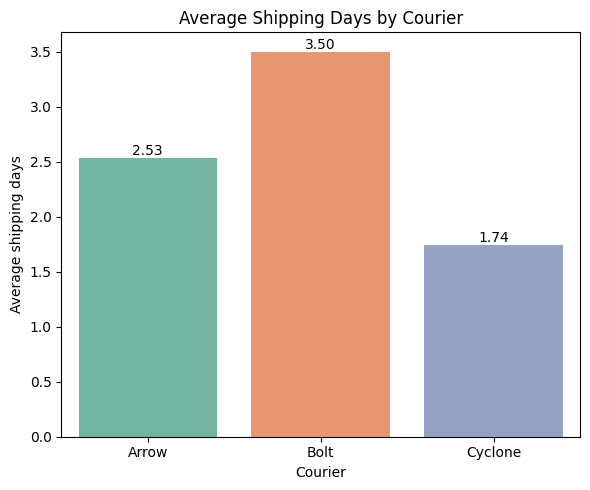

In [21]:
# Avg shipping days
plt.figure(figsize=(6,5))
ax =sns.barplot(
    data=courier_perf,
    x="courier",
    y="avg_shipping_days",
    hue="courier",
    palette="Set2"
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom"
    )

plt.title("Average Shipping Days by Courier")
plt.xlabel("Courier")
plt.ylabel("Average shipping days")
plt.tight_layout()
plt.show()

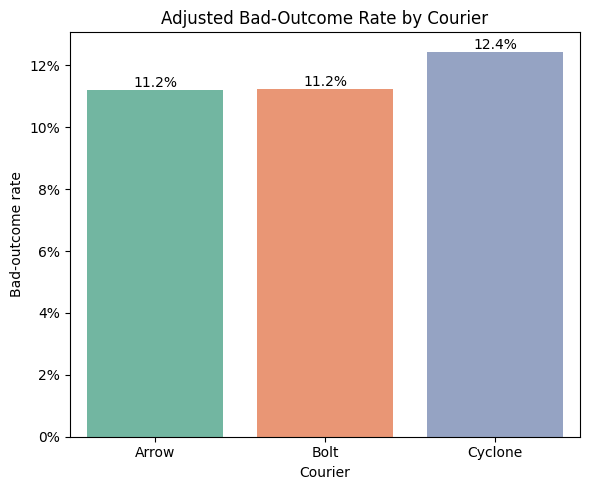

In [22]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=courier_perf,
    x="courier",
    y="bad_outcome_rate_adjusted",
    hue="courier",
    palette="Set2"
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1%}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom"
    )

plt.title("Adjusted Bad-Outcome Rate by Courier")
plt.xlabel("Courier")
plt.ylabel("Bad-outcome rate")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

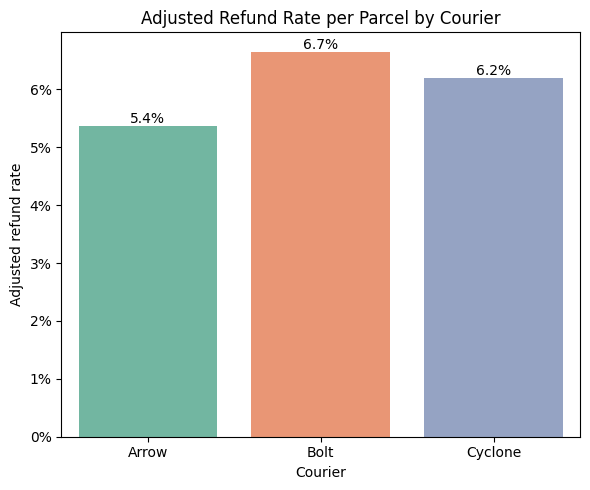

In [23]:
plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=courier_perf,
    x="courier",
    y="adjusted_refund_rate_parcel",
    hue="courier",
    palette="Set2"
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1%}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom"
    )

plt.title("Adjusted Refund Rate per Parcel by Courier")
plt.xlabel("Courier")
plt.ylabel("Adjusted refund rate")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

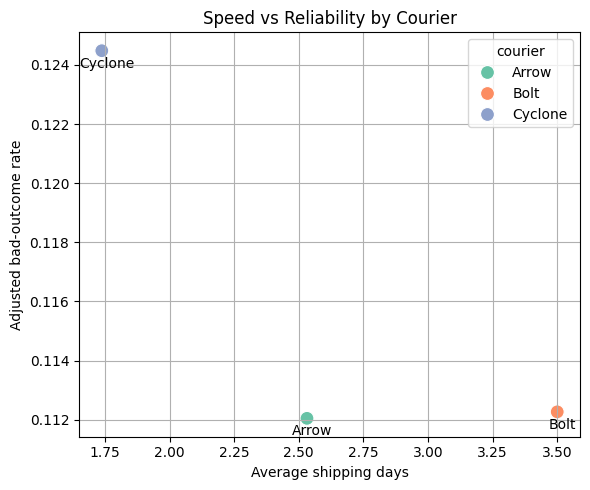

In [24]:
plt.figure(figsize=(6,5))
plt.grid()

ax = sns.scatterplot(
    data=courier_perf,
    x="avg_shipping_days",
    y="bad_outcome_rate_adjusted",
    hue="courier",
    palette="Set2",
    s=100
)
plt.title("Speed vs Reliability by Courier")
plt.xlabel("Average shipping days")
plt.ylabel("Adjusted bad-outcome rate")

for _, row in courier_perf.iterrows():
    plt.text(
        row["avg_shipping_days"] + 0.02, 
        row["bad_outcome_rate_adjusted"] - 0.0002,
        row["courier"],
        horizontalalignment='center',
        verticalalignment='top'
    )

plt.tight_layout()
plt.show()

Segmented courier strategy: how would you assign couriers to regions or product categories to improve performance? Justify your recommendation with data / visuals

In [25]:
# Courier x region performance
courier_region = (
    shipments_non_cancel.assign(is_bad_adjusted=adjusted_bad_mask.astype(int)).merge(orders[["order_id", "region"]], on="order_id", how="left").groupby(["courier", "region"], as_index=False).agg(
        parcels=("shipment_id", "count"),
        avg_shipping_days=("shipping_days", "mean"),
        bad_parcels_adjusted=("is_bad_adjusted", "sum"),
        non_cancel_refunded_parcels=("is_refunded_non_cancel", "sum")
    )
)

courier_region["bad_outcome_rate_adjusted"] = (
    courier_region["bad_parcels_adjusted"] / courier_region["parcels"]
)

courier_region["adjusted_refund_rate_parcel"] = (
    courier_region["non_cancel_refunded_parcels"] / courier_region["parcels"]
)

courier_region.sort_values(["region", "bad_outcome_rate_adjusted", "avg_shipping_days"])

,courier,region,parcels,avg_shipping_days,bad_parcels_adjusted,non_cancel_refunded_parcels,bad_outcome_rate_adjusted,adjusted_refund_rate_parcel
0,Arrow,East,455,2.464037,45,23,0.098901,0.050549
4,Bolt,East,490,3.491379,57,32,0.116327,0.065306
8,Cyclone,East,455,1.708235,56,29,0.123077,0.063736
5,Bolt,North,442,3.607059,45,30,0.101810,0.067873
1,Arrow,North,516,2.540041,56,27,0.108527,0.052326
9,Cyclone,North,482,1.763636,68,28,0.141079,0.058091
10,Cyclone,South,595,1.772242,65,34,0.109244,0.057143
6,Bolt,South,596,3.500000,68,39,0.114094,0.065436
2,Arrow,South,554,2.552529,66,26,0.119134,0.046931
7,Bolt,West,396,3.387701,46,27,0.116162,0.068182


In [26]:
# Courier x category
courier_category = (
    shipments_non_cancel.assign(is_bad_adjusted=adjusted_bad_mask.astype(int)).merge(orders[["order_id", "category", "order_value"]], on="order_id", how="left").groupby(["courier", "category"], as_index=False).agg(
        parcels=("shipment_id", "count"),
        avg_shipping_days=("shipping_days", "mean"),
        bad_parcels_adjusted=("is_bad_adjusted", "sum"),
        non_cancel_refunded_parcels=("is_refunded_non_cancel", "sum"),
        total_order_value=("order_value", "sum")
    )
)

courier_category["bad_outcome_rate_adjusted"] = (
    courier_category["bad_parcels_adjusted"] / courier_category["parcels"]
)

courier_category["adjusted_refund_rate_parcel"] = (
    courier_category["non_cancel_refunded_parcels"] / courier_category["parcels"]
)

courier_category.sort_values(["category", "bad_outcome_rate_adjusted", "avg_shipping_days"])

,courier,category,parcels,avg_shipping_days,bad_parcels_adjusted,non_cancel_refunded_parcels,total_order_value,bad_outcome_rate_adjusted,adjusted_refund_rate_parcel
5,Bolt,Clothing,386,3.476839,44,27,23439.76,0.113990,0.069948
0,Arrow,Clothing,397,2.508065,48,25,23692.71,0.120907,0.062972
10,Cyclone,Clothing,362,1.695783,50,22,21837.26,0.138122,0.060773
6,Bolt,Electronics,484,3.562092,56,33,57746.24,0.115702,0.068182
1,Arrow,Electronics,499,2.509554,60,33,59468.39,0.120240,0.066132
11,Cyclone,Electronics,487,1.704595,60,34,58325.44,0.123203,0.069815
2,Arrow,Home,482,2.533769,41,18,38421.49,0.085062,0.037344
7,Bolt,Home,504,3.484211,57,29,40513.92,0.113095,0.057540
12,Cyclone,Home,498,1.776119,58,29,40177.36,0.116466,0.058233
8,Bolt,Sports,285,3.533088,31,19,19773.69,0.108772,0.066667


In [27]:
# Courier x category continued - net revenue per parcel
q8_sorted

,courier,category,parcels,total_order_value,total_refund_amount,net_revenue,net_revenue_per_parcel
1,Arrow,Electronics,499,59468.39,2492.575,56975.815,114.179990
6,Bolt,Electronics,484,57746.24,2977.505,54768.735,113.158543
11,Cyclone,Electronics,487,58325.44,3396.410,54929.030,112.790616
2,Arrow,Home,482,38421.49,1146.350,37275.140,77.334315
12,Cyclone,Home,498,40177.36,1854.170,38323.190,76.954197
7,Bolt,Home,504,40513.92,1933.330,38580.590,76.548790
13,Cyclone,Sports,264,18578.60,841.185,17737.415,67.187178
3,Arrow,Sports,256,17848.38,782.580,17065.800,66.663281
8,Bolt,Sports,285,19773.69,1012.835,18760.855,65.827561
5,Bolt,Clothing,386,23439.76,1277.525,22162.235,57.415117


In [28]:
# Order value average by category
category_avg = (
    orders.groupby("category", as_index=False).agg(avg_order_value=("order_value", "mean"))
)

category_avg

,category,avg_order_value
0,Clothing,60.188735
1,Electronics,119.599543
2,Home,80.163936
3,Sports,70.029341
4,Toys,40.078806


In [29]:
# Variance in delivery time by courier
courier_variance = (
    delivered.groupby("courier", as_index=False).agg(
        shipping_days_variance=("shipping_days", "var"),
        shipping_days_stddev=("shipping_days", "std"),
        parcels_delivered=("shipment_id", "count")
    )
)

courier_variance

,courier,shipping_days_variance,shipping_days_stddev,parcels_delivered
0,Arrow,1.348804,1.161380,1787
1,Bolt,1.512719,1.229926,1829
2,Cyclone,0.798437,0.893553,1793


In [ ]:
# Test for statistically significant difference in bad outcome rate
# for category

def test_bad_rate_diffs(courier_category, alpha=0.05):
    """
    For each category, test pairwise differences in bad-outcome rates
    between couriers using two-proportion z-tests.
    Returns a DataFrame with z, p, and significance flags.
    """
    results = []

    # unique categories and couriers
    categories = courier_category["category"].unique()
    couriers = courier_category["courier"].unique()

    for cat in categories:
        df_cat = courier_category[courier_category["category"] == cat]

        # all courier pairs for this category
        for c1, c2 in itertools.combinations(couriers, 2):
            row1 = df_cat[df_cat["courier"] == c1].iloc[0]
            row2 = df_cat[df_cat["courier"] == c2].iloc[0]

            x = [row1["bad_parcels_adjusted"], row2["bad_parcels_adjusted"]]
            n = [row1["parcels"],            row2["parcels"]]

            z_stat, p_value = proportions_ztest(x, n)

            results.append({
                "category": cat,
                "courier_1": c1,
                "courier_2": c2,
                "bad_rate_1": row1["bad_outcome_rate_adjusted"],
                "bad_rate_2": row2["bad_outcome_rate_adjusted"],
                "z_stat": z_stat,
                "p_value": p_value,
                "significant_5pct": p_value < alpha
            })

    return pd.DataFrame(results)

bad_rate_tests = test_bad_rate_diffs(courier_category, alpha=0.05)
bad_rate_tests

,category,courier_1,courier_2,bad_rate_1,bad_rate_2,z_stat,p_value,significant_5pct
0,Clothing,Arrow,Bolt,0.120907,0.113990,0.300514,0.763785,False
1,Clothing,Arrow,Cyclone,0.120907,0.138122,-0.706411,0.479933,False
2,Clothing,Bolt,Cyclone,0.113990,0.138122,-0.995033,0.319720,False
3,Electronics,Arrow,Bolt,0.120240,0.115702,0.220483,0.825495,False
4,Electronics,Arrow,Cyclone,0.120240,0.123203,-0.142268,0.886868,False
5,Electronics,Bolt,Cyclone,0.115702,0.123203,-0.360324,0.718605,False
6,Home,Arrow,Bolt,0.085062,0.113095,-1.470711,0.141369,False
7,Home,Arrow,Cyclone,0.085062,0.116466,-1.630893,0.102913,False
8,Home,Bolt,Cyclone,0.113095,0.116466,-0.167365,0.867083,False
9,Sports,Arrow,Bolt,0.140625,0.108772,1.122964,0.261453,False


In [39]:
# Test for statistically significant difference in bad outcome rate
# for region

def test_bad_rate_diffs_region(courier_region, alpha=0.05):
    """
    For each region, test pairwise differences in bad-outcome rates
    between couriers using two-proportion z-tests.
    Returns a DataFrame with z, p, and significance flags.
    """
    results = []

    # unique regions and couriers
    regions = courier_region["region"].unique()
    couriers = courier_region["courier"].unique()

    for reg in regions:
        df_reg = courier_region[courier_region["region"] == reg]

        # all courier pairs for this region
        for c1, c2 in itertools.combinations(couriers, 2):
            row1 = df_reg[df_reg["courier"] == c1].iloc[0]
            row2 = df_reg[df_reg["courier"] == c2].iloc[0]

            x = [row1["bad_parcels_adjusted"], row2["bad_parcels_adjusted"]]
            n = [row1["parcels"],            row2["parcels"]]

            z_stat, p_value = proportions_ztest(x, n)

            results.append({
                "region": reg,
                "courier_1": c1,
                "courier_2": c2,
                "bad_rate_1": row1["bad_outcome_rate_adjusted"],
                "bad_rate_2": row2["bad_outcome_rate_adjusted"],
                "z_stat": z_stat,
                "p_value": p_value,
                "significant_5pct": p_value < alpha
            })

    return pd.DataFrame(results)

bad_rate_tests_region = test_bad_rate_diffs_region(courier_region, alpha=0.05)
bad_rate_tests_region

,region,courier_1,courier_2,bad_rate_1,bad_rate_2,z_stat,p_value,significant_5pct
0,East,Arrow,Bolt,0.098901,0.116327,-0.862560,0.388379,False
1,East,Arrow,Cyclone,0.098901,0.123077,-1.160856,0.245700,False
2,East,Bolt,Cyclone,0.116327,0.123077,-0.319557,0.749304,False
3,North,Arrow,Bolt,0.108527,0.101810,0.337485,0.735751,False
4,North,Arrow,Cyclone,0.108527,0.141079,-1.557833,0.119273,False
5,North,Bolt,Cyclone,0.101810,0.141079,-1.819992,0.068760,False
6,South,Arrow,Bolt,0.119134,0.114094,0.266149,0.790124,False
7,South,Arrow,Cyclone,0.119134,0.109244,0.527054,0.598156,False
8,South,Bolt,Cyclone,0.114094,0.109244,0.265726,0.790450,False
9,West,Arrow,Bolt,0.122340,0.116162,0.264854,0.791122,False


In [ ]:
# Test if shipping times are significantly different between couriers using ANOVA
from scipy.stats import f_oneway

courier_groups = [group["shipping_days"].values for name, group in delivered.groupby("courier")]
f_stat, p_value = f_oneway(*courier_groups)
print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_value)

ANOVA F-statistic: 1154.669993147303
ANOVA p-value: 0.0


[array([4., 2., 3., ..., 2., 4., 3.], shape=(1787,)),
 array([3., 4., 3., ..., 3., 3., 3.], shape=(1829,)),
 array([1., 2., 1., ..., 1., 2., 2.], shape=(1793,))]

Plots

Speed by region

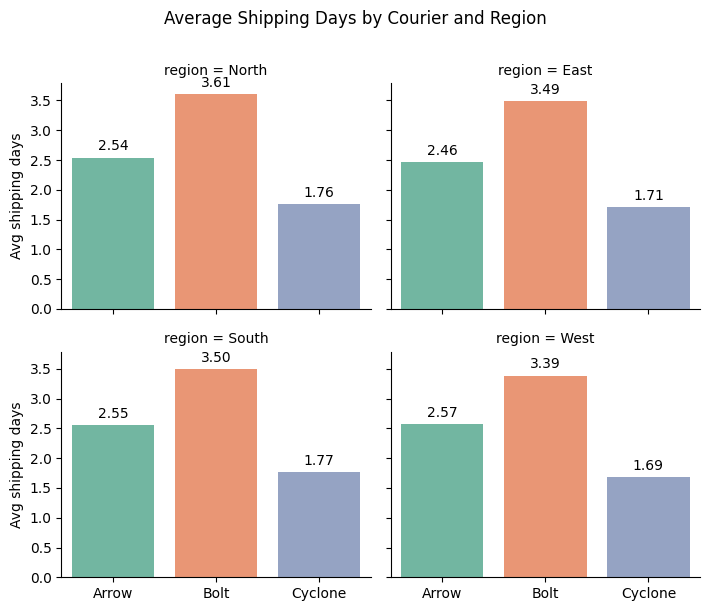

In [31]:
region_order = ["North", "East", "South", "West"]
courier_region_display = courier_region.copy()
courier_region_display["region"] = pd.Categorical(
    courier_region_display["region"], categories=region_order, ordered=True
)

# Avg shipping days by courier & region
g = sns.FacetGrid(
    courier_region_display,
    col="region",
    col_wrap=2,
    sharey=True,
    height=3.0,
    aspect=1.2
)
g.map_dataframe(
    sns.barplot,
    x="courier",
    y="avg_shipping_days",
    hue="courier",
    palette="Set2",
    dodge=False
)

for ax in g.axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("Avg shipping days")
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points"
        )

g.figure.suptitle("Average Shipping Days by Courier and Region", y=1.01)
plt.tight_layout()
plt.show()

Bad outcome rate by region

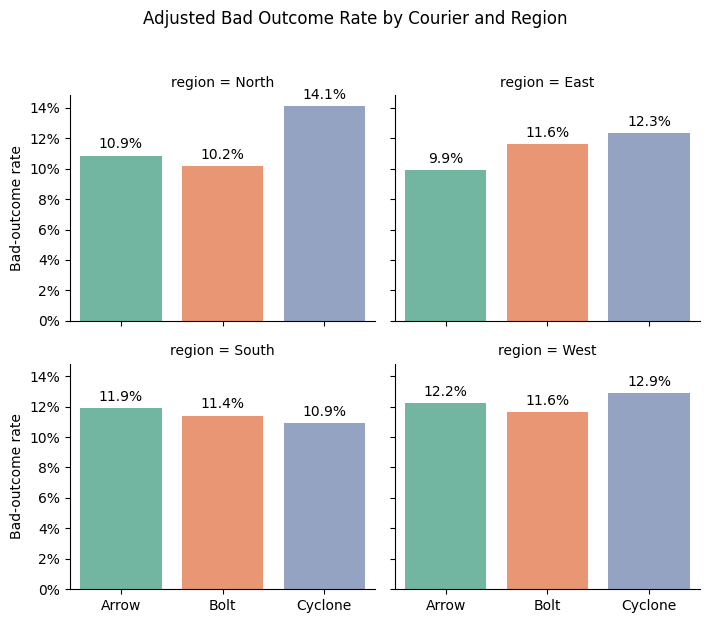

In [32]:
g = sns.FacetGrid(
    courier_region_display,
    col="region",
    col_wrap=2,
    sharey=True,
    height=3.0,
    aspect=1.2
)
g.map_dataframe(
    sns.barplot,
    x="courier",
    y="bad_outcome_rate_adjusted",
    hue="courier",
    palette="Set2",
    dodge=False
)

for ax in g.axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("Bad-outcome rate")
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}")
    )
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1%}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points"
        )

g.figure.suptitle("Adjusted Bad Outcome Rate by Courier and Region", y=1.03)
plt.tight_layout()
plt.show()

Speed by category

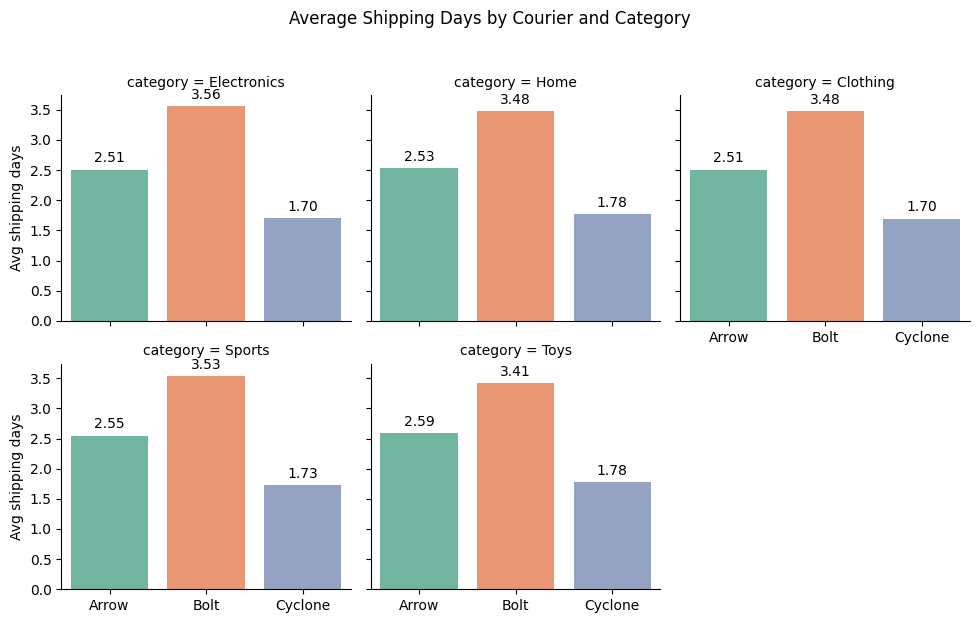

In [33]:
courier_category_display = courier_category.copy()
cat_order = ["Electronics", "Home", "Clothing", "Sports", "Toys"]
courier_category_display["category"] = pd.Categorical(
    courier_category_display["category"], categories=cat_order, ordered=True
)

g = sns.FacetGrid(
    courier_category_display,
    col="category",
    col_wrap=3,
    sharey=True,
    height=3.0,
    aspect=1.1
)
g.map_dataframe(
    sns.barplot,
    x="courier",
    y="avg_shipping_days",
    hue="courier",
    palette="Set2",
    dodge=False
)

for ax in g.axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("Avg shipping days")
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points"
        )

g.figure.suptitle("Average Shipping Days by Courier and Category", y=1.03)
plt.tight_layout()
plt.show()

Bad outcome rate by category

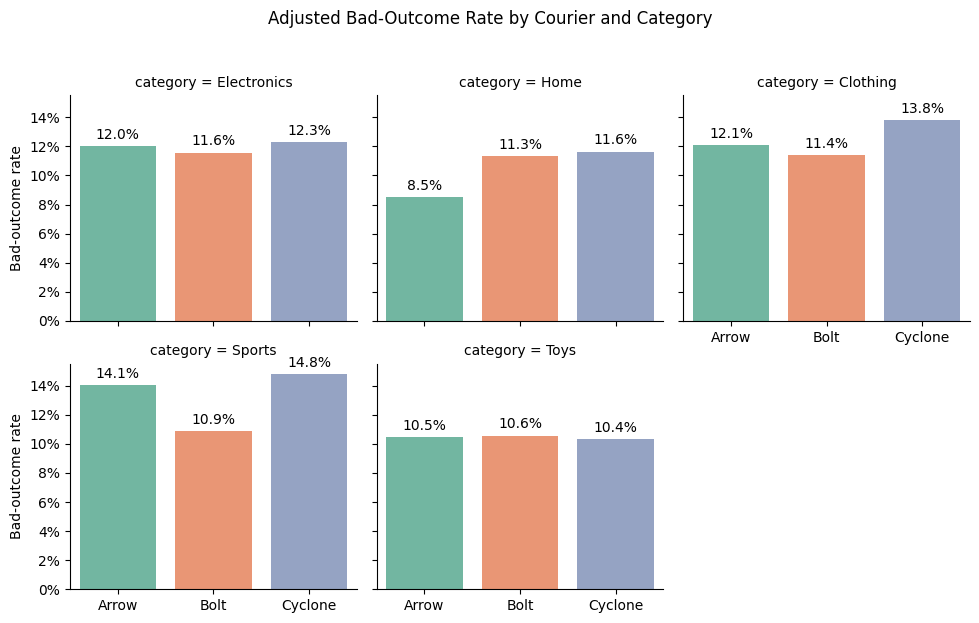

In [34]:
g = sns.FacetGrid(
    courier_category_display,
    col="category",
    col_wrap=3,
    sharey=True,
    height=3.0,
    aspect=1.1
)
g.map_dataframe(
    sns.barplot,
    x="courier",
    y="bad_outcome_rate_adjusted",
    hue="courier",
    palette="Set2",
    dodge=False
)

for ax in g.axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("Bad-outcome rate")
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}")
    )
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1%}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points"
        )

g.figure.suptitle("Adjusted Bad-Outcome Rate by Courier and Category", y=1.03)
plt.tight_layout()
plt.show()

Adjusted Refund Rate by Category

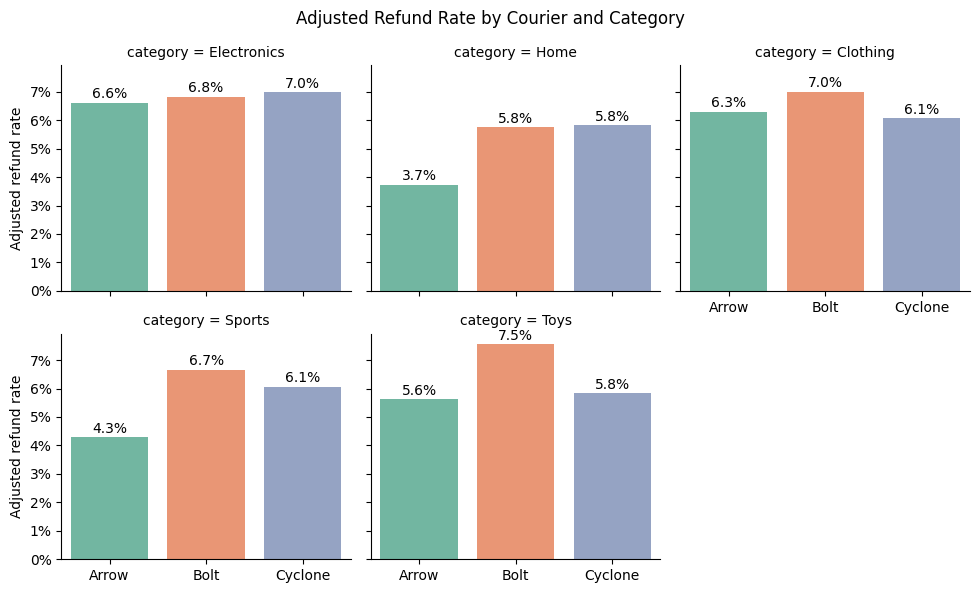

In [35]:
g = sns.FacetGrid(
    courier_category_display,
    col="category",
    col_wrap=3,
    sharey=True,
    height=3.0,
    aspect=1.1
)

g.map_dataframe(
    sns.barplot,
    x="courier",
    y="adjusted_refund_rate_parcel",
    hue="courier",
    palette="Set2",
    dodge=False
)

for ax in g.axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("Adjusted refund rate")
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}")
    )
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1%}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 1),
            textcoords="offset points"
        )

g.figure.suptitle("Adjusted Refund Rate by Courier and Category")
plt.tight_layout()
plt.show()

Adjusted Refund Rate by Region

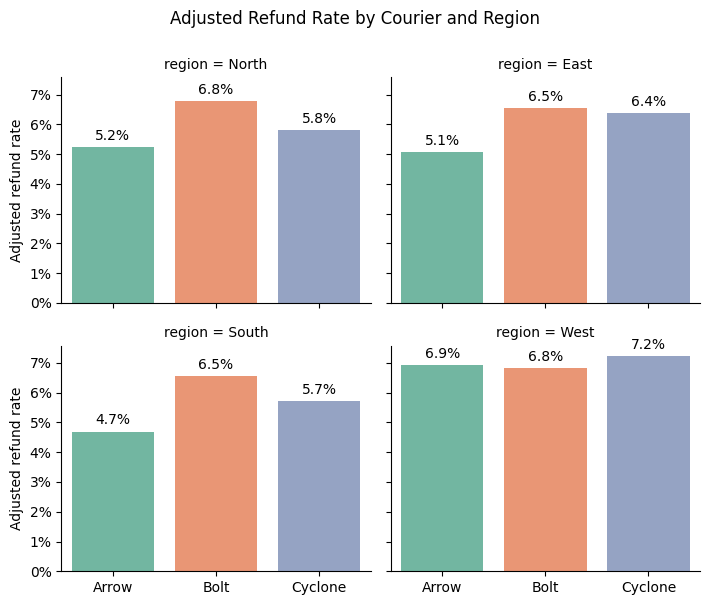

In [36]:
g = sns.FacetGrid(
    courier_region_display,
    col="region",
    col_wrap=2,
    sharey=True,
    height=3.0,
    aspect=1.2
)
g.map_dataframe(
    sns.barplot,
    x="courier",
    y="adjusted_refund_rate_parcel",
    hue="courier",
    palette="Set2",
    dodge=False
)

for ax in g.axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("Adjusted refund rate")
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}")
    )
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1%}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points"
        )

g.figure.suptitle("Adjusted Refund Rate by Courier and Region", y=1.0)
plt.tight_layout()
plt.show()

Net revenue per parcel by category

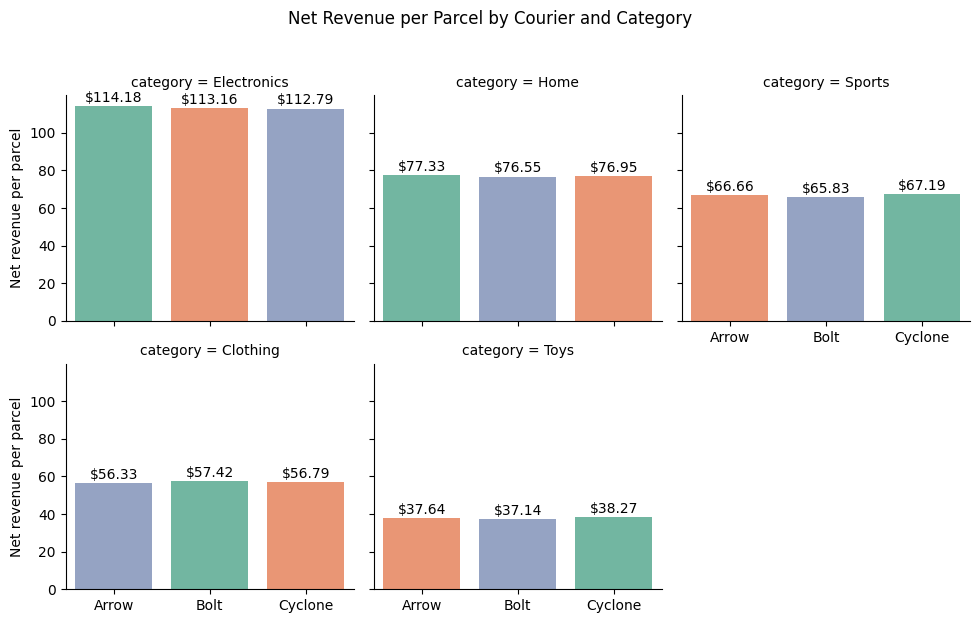

In [37]:
g = sns.FacetGrid(
    q8_sorted,
    col="category",
    col_wrap=3,
    sharey=True,
    height=3.0,
    aspect=1.1
)

g.map_dataframe(
    sns.barplot,
    x="courier",
    y="net_revenue_per_parcel",
    hue="courier",
    palette="Set2",
    dodge=False
)

for ax in g.axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("Net revenue per parcel")
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"${height:.2f}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 1),
            textcoords="offset points"
        )

g.figure.suptitle("Net Revenue per Parcel by Courier and Category", y=1.03)
plt.tight_layout()
plt.show()

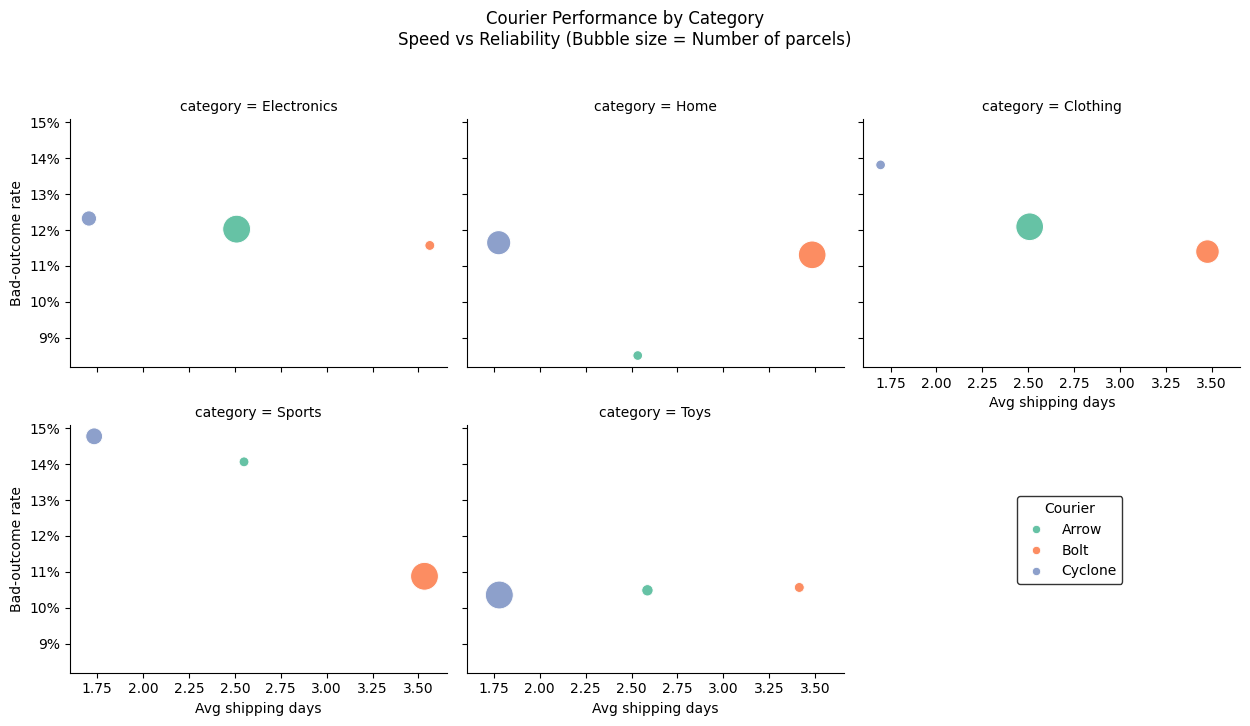

In [38]:
# Ensure ordered categories
cat_order = ["Electronics", "Home", "Clothing", "Sports", "Toys"]
plot_df = courier_category.copy()
plot_df["category"] = pd.Categorical(
    plot_df["category"], categories=cat_order, ordered=True
)

# Scale bubble size for plotting
plot_df["bubble_size"] = plot_df["parcels"]

g = sns.FacetGrid(
    plot_df,
    col="category",
    col_wrap=3,
    height=3.5,
    aspect=1.1,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="avg_shipping_days",
    y="bad_outcome_rate_adjusted",
    hue="courier",
    size="bubble_size",
    sizes=(50, 400),
    palette="Set2"
)

for ax in g.axes.flat:
    ax.set_xlabel("Avg shipping days")
    ax.set_ylabel("Bad-outcome rate")
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}")
    )

g.add_legend(
    title="Courier",
    label_order=plot_df["courier"].unique(),
    bbox_to_anchor=(0.9, 0.2),
    loc="lower right"
    )

leg = g._legend
leg.set_frame_on(True)
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.0)

g.figure.suptitle(
    "Courier Performance by Category\nSpeed vs Reliability (Bubble size = Number of parcels)",
    y=1.03
)

plt.tight_layout()
plt.show()

Operational improvements: recommend two operational changes (beyond
changing courier allocation) to reduce refund-related losses, using insights from your
analysis

In [44]:
# Refund reason distribution
refund_reason_dist = (
    refunds.groupby("refund_reason", as_index=False).agg(count=("refund_id", "nunique"))
)

refund_reason_dist["percent"] = refund_reason_dist["count"] / refund_reason_dist["count"].sum()

refund_reason_dist.sort_values("percent", ascending=False)

,refund_reason,count,percent
2,Late,116,0.288557
0,Customer Cancelled,102,0.253731
3,Wrong Item,102,0.253731
1,Damaged,82,0.203980


In [45]:
# Refund amount by reason
refund_amount_reason = (
    refunds.groupby("refund_reason", as_index=False).agg(total_refund_amount=("refund_amount", "sum"))
)
refund_amount_reason["percent"] = refund_amount_reason["total_refund_amount"] / refund_amount_reason["total_refund_amount"].sum()

refund_amount_reason.sort_values("percent", ascending=False)

,refund_reason,total_refund_amount,percent
2,Late,6647.74,0.299118
3,Wrong Item,5312.46,0.239037
0,Customer Cancelled,5188.38,0.233454
1,Damaged,5075.87,0.228391


In [50]:
import pandas as pd

# Join order_date onto shipments
shipments_with_order = shipments.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)

# Compute ship_delay in days (float)
shipments_with_order["ship_delay_days"] = (
    (shipments_with_order["ship_date"] - shipments_with_order["order_date"]).dt.total_seconds() / (24 * 60 * 60)
)

shipments_orders = shipments_with_order.merge(
    orders,
    on="order_id",
    how="left",
    suffixes=("", "_orders")
)

In [54]:
delay_region = (
    shipments_orders.groupby("region", as_index=False).agg(
        parcels=("shipment_id", "count"),
        avg_ship_delay_days=("ship_delay_days", "mean")
    )
)

delay_region

,region,parcels,avg_ship_delay_days
0,East,1400,0.969286
1,North,1440,0.978472
2,South,1745,0.979943
3,West,1160,0.994828


In [55]:
delay_category = (
    shipments_orders.groupby("category", as_index=False).agg(
        parcels=("shipment_id", "count"),
        avg_ship_delay_days=("ship_delay_days", "mean")
    )
)

delay_category

,category,parcels,avg_ship_delay_days
0,Clothing,1145,0.991266
1,Electronics,1470,0.982993
2,Home,1484,0.962938
3,Sports,805,1.013665
4,Toys,841,0.957194


In [56]:
# Average refund date - order date for refunded orders
refunds_with_order = refunds.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)

refunds_with_order["refund_delay_days"] = (
    (refunds_with_order["refund_date"] - refunds_with_order["order_date"]).dt.total_seconds() / (24 * 60 * 60)
)

refund_delay = refunds_with_order.groupby("refund_reason", as_index=False).agg(
    avg_refund_delay_days=("refund_delay_days", "mean"),
    count=("refund_id", "nunique")
)

refund_delay.sort_values("avg_refund_delay_days", ascending=False)

,refund_reason,avg_refund_delay_days,count
2,Late,15.551724,116
3,Wrong Item,14.990196,102
1,Damaged,14.951220,82
0,Customer Cancelled,14.892157,102


In [57]:
# Average ship delay
avg_ship_delay = shipments_with_order["ship_delay_days"].mean()
print(f"Average ship delay (days): {avg_ship_delay:.2f}")

Average ship delay (days): 0.98
